In [37]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from clusterprep import plot_history

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight'})

In [81]:
# Modifier uniquement cette cellule pour analyser un autre run.
run_dir = Path('/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b')
run_dir = run_dir.expanduser().resolve()
output_dir = run_dir / 'analysis'
output_dir.mkdir(exist_ok=True)

assert run_dir.is_dir(), f'Run introuvable: {run_dir}'
print(f'Run: {run_dir}')
print(f'Rapports: {output_dir}')

Run: /Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b
Rapports: /Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b/analysis


In [82]:
def _read_json(name, default=None):
    path = run_dir / name
    if not path.exists():
        return default
    return json.loads(path.read_text())


def _read_csv(name):
    path = run_dir / name
    return pd.read_csv(path) if path.exists() else None


def _save(fig, name):
    path = output_dir / name
    fig.savefig(path)
    print(f'Sauvegarde: {path}')
    return path


config_doc = _read_json('config.json', {}) or {}
config = config_doc.get('config', config_doc)
metrics = _read_json('metrics.json', {}) or {}
report = _read_json('report.json', {}) or {}
status = _read_json('status.json', {}) or {}
preprocessing = _read_json('preprocessing.json', {}) or {}
splits = _read_json('splits.json', {}) or {}

history = _read_csv('history.csv')
validation = _read_csv('validation_predictions.csv')
test = _read_csv('test_predictions.csv')

files = sorted(p for p in run_dir.rglob('*') if p.is_file())
artifact_table = pd.DataFrame({
    'artifact': [str(p.relative_to(run_dir)) for p in files],
    'size_kb': [round(p.stat().st_size / 1024, 1) for p in files],
})

summary = {
    'status': status.get('status'),
    'model': config.get('model'),
    'mode': config.get('mode'),
    'epochs_ran': metrics.get('epochs_ran'),
    'best_epoch': metrics.get('best_epoch'),
    'train_seconds': metrics.get('seconds'),
    'classes': metrics.get('class_names', config_doc.get('class_names')),
    'artifacts': len(files),
}
display(pd.Series(summary, name='run'))
display(artifact_table)

print('Tables disponibles:', {
    'history': None if history is None else history.shape,
    'validation': None if validation is None else validation.shape,
    'test': None if test is None else test.shape,
})

status            completed
model             image_cnn
mode                    raw
epochs_ran              195
best_epoch              145
train_seconds    616.357757
classes           [DE, NDE]
artifacts                10
Name: run, dtype: object

,artifact,size_kb
0,best.pt,858.4
1,config.json,4.1
2,history.csv,60.6
3,history.jsonl,279.7
4,metrics.json,6.5
5,preprocessing.json,0.1
6,splits.json,154.1
7,status.json,0.0
8,test_predictions.csv,4.6
9,validation_predictions.csv,4.6


Tables disponibles: {'history': (195, 19), 'validation': (42, 8), 'test': (42, 8)}


In [83]:
if history is None:
    history_jsonl = run_dir / 'history.jsonl'
    if history_jsonl.exists():
        history = pd.DataFrame(json.loads(line) for line in history_jsonl.read_text().splitlines() if line.strip())
        rows = []
        for record in history.to_dict('records'):
            row = {'epoch': record.get('epoch'), 'seconds': record.get('seconds'), 'learning_rate': record.get('learning_rate')}
            for split_name in ('train', 'validation'):
                for key, value in (record.get(split_name) or {}).items():
                    if np.isscalar(value):
                        row[f'{split_name}_{key}'] = value
            rows.append(row)
        history = pd.DataFrame(rows)
        print('Historique charge depuis history.jsonl:', history.shape)

## 1. Configuration et synthese

Cette section recense les fichiers du run, affiche la configuration exacte du modele et compare les metriques de validation, de test et des cohortes disponibles.

In [84]:
print('Configuration du modele')
display(pd.Series(config, name='value').to_frame())

metric_rows = []
for split_name in ('validation', 'test'):
    values = metrics.get(split_name, {})
    if values:
        row = {'split': split_name, **{k: v for k, v in values.items() if np.isscalar(v)}}
        metric_rows.append(row)
for cohort_name, cohort in metrics.get('test_cohorts', {}).items():
    values = cohort.get('metrics', {})
    if not values:
        print(f'Attention: pas de metriques pour le cohort {cohort_name}.')
        break
    metric_rows.append({
        'split': f'test:{cohort_name}',
        **{k: v for k, v in values.items() if np.isscalar(v)},
    })

if metric_rows:
    summary_metrics = pd.DataFrame(metric_rows).set_index('split')
    display(summary_metrics.style.format(precision=3))
else:
    print('Aucune metrique finale structuree dans metrics.json.')

print('Pretraitement:', preprocessing)
print('Splits:', {name: len(values) for name, values in splits.items()})

Configuration du modele


,value
epochs,200
batch_size,16
learning_rate,0.00005
weight_decay,0.1
use_class_weights,True
label_smoothing,0.1
use_scheduler,True
scheduler,onecycle
max_lr_factor,3.0
warmup_fraction,0.3


,n_samples,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_macro,average_precision_macro,loss
split,,,,,,,,
validation,42,0.881,0.914,0.872,0.885,0.944,0.903,0.463
test,42,0.738,0.696,0.700,0.736,0.760,0.730,0.660
test:all,42,0.738,0.696,0.700,0.736,0.760,0.730,0.559
test:paired,15,0.733,0.833,0.700,0.760,0.833,0.746,0.597
test:raw_only,27,0.741,0.400,0.426,0.788,0.560,0.540,0.539


Pretraitement: {'created': 0, 'reused': 207, 'rebuilt': 0, 'fits_warnings': 0, 'seconds': 0.4072247090516612}
Splits: {'train': 123, 'validation': 42, 'test': 42, 'base_splits': 3, 'samples': 207, 'source_signatures': 207}


## 2. Courbes d'apprentissage

Les courbes brutes de `history.csv` sont tracees pour la perte, l'accuracy, le F1 macro et l'AUC ROC, avec une ligne verticale sur la meilleure epoque selon `metrics.json`.

Sauvegarde: /Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b/analysis/learning_curves.png


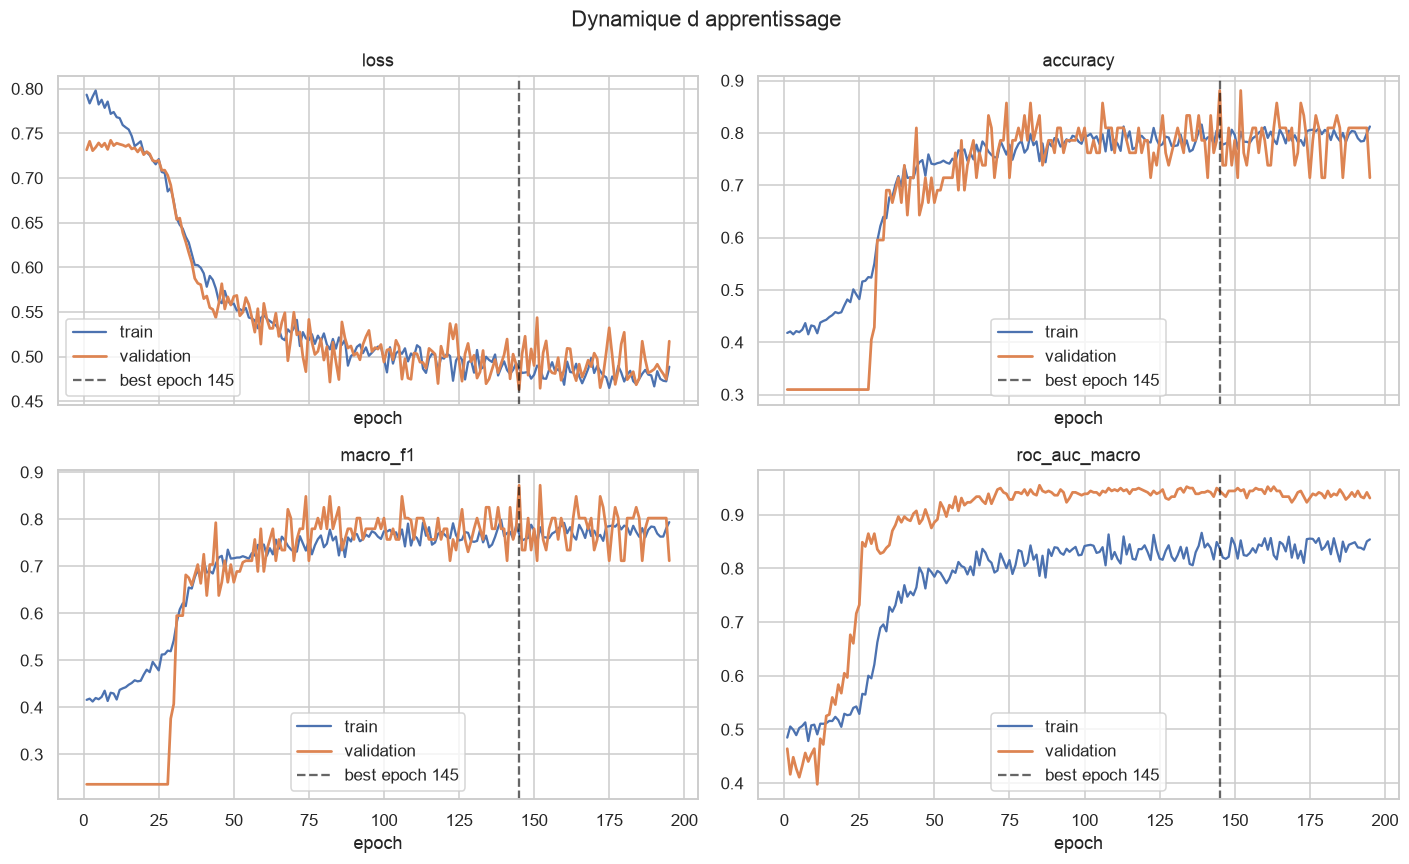

,epoch,seconds,learning_rate,train_n_samples,train_accuracy,train_balanced_accuracy,train_macro_f1,train_weighted_f1,train_roc_auc_macro,train_average_precision_macro,train_loss,val_n_samples,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_roc_auc_macro,val_average_precision_macro,val_loss
185,186,3.154173,3.668521e-06,2944,0.799932,0.793967,0.781028,0.803451,0.849880,0.811950,0.480755,42,0.714286,0.793103,0.711670,0.722131,0.938992,0.896029,0.517228
186,187,3.164708,3.166646e-06,2944,0.782609,0.773059,0.761386,0.786331,0.830721,0.792063,0.485139,42,0.785714,0.844828,0.779592,0.793586,0.928382,0.885144,0.496756
187,188,3.164169,2.700942e-06,2944,0.797215,0.789378,0.777368,0.800624,0.844019,0.806140,0.479851,42,0.809524,0.862069,0.802353,0.816695,0.933687,0.890387,0.481744
188,189,3.144895,2.271643e-06,2944,0.803668,0.796397,0.784405,0.806908,0.846424,0.809091,0.478975,42,0.809524,0.862069,0.802353,0.816695,0.941645,0.898180,0.483562
189,190,3.136735,1.878964e-06,2944,0.802310,0.796334,0.783298,0.805798,0.848760,0.812777,0.466648,42,0.809524,0.862069,0.802353,0.816695,0.933687,0.890387,0.485989
190,191,3.142914,1.523105e-06,2944,0.789742,0.781482,0.769471,0.793341,0.839106,0.801030,0.483696,42,0.809524,0.862069,0.802353,0.816695,0.944297,0.901784,0.491445
191,192,3.139579,1.204243e-06,2944,0.783628,0.775442,0.762976,0.787501,0.838359,0.802831,0.475059,42,0.809524,0.862069,0.802353,0.816695,0.933687,0.890547,0.485519
192,193,3.156967,9.225405e-07,2944,0.784647,0.773469,0.763093,0.787996,0.834977,0.794774,0.472991,42,0.809524,0.862069,0.802353,0.816695,0.931034,0.887296,0.480676
193,194,3.153304,6.781379e-07,2944,0.799592,0.793916,0.780705,0.803178,0.850302,0.811371,0.472375,42,0.809524,0.862069,0.802353,0.816695,0.941645,0.899268,0.474626
194,195,3.143485,4.711588e-07,2944,0.812160,0.806203,0.793776,0.815277,0.854040,0.820467,0.488654,42,0.714286,0.793103,0.711670,0.722131,0.931034,0.888512,0.517248


In [85]:
if history is None or history.empty:
    print('history.csv absent: utilisation de history.jsonl impossible sans rechargement.')
else:
    metric_specs = [
        ('loss', 'train_loss', 'val_loss'),
        ('accuracy', 'train_accuracy', 'val_accuracy'),
        ('macro_f1', 'train_macro_f1', 'val_macro_f1'),
        ('roc_auc_macro', 'train_roc_auc_macro', 'val_roc_auc_macro'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
    best_epoch = metrics.get('best_epoch')
    for ax, (label, train_col, val_col) in zip(axes.flat, metric_specs):
        if train_col in history:
            ax.plot(history['epoch'], history[train_col], label='train', linewidth=1.5)
        if val_col in history:
            ax.plot(history['epoch'], history[val_col], label='validation', linewidth=1.8)
        if best_epoch is not None:
            ax.axvline(best_epoch, color='black', linestyle='--', alpha=0.6, label=f'best epoch {best_epoch}')
        ax.set_title(label)
        ax.set_xlabel('epoch')
        ax.legend()
    fig.suptitle('Dynamique d apprentissage')
    fig.tight_layout()
    _save(fig, 'learning_curves.png')
    plt.show()

    display(history.tail(10))

## 3. Evaluation detaillee des predictions

Les CSV de validation et de test sont analyses independamment. Les calculs sont refaits depuis `label`, `prediction` et `probability_*`, ce qui permet d'explorer les seuils et les erreurs au-dela des metriques agregees.

In [86]:
def _prediction_metrics(frame):
    if frame is None or frame.empty:
        return None
    y_true = frame['label'].astype(int).to_numpy()
    y_pred = frame['prediction'].astype(int).to_numpy()
    result = {
        'n': len(frame),
        'accuracy': float((y_true == y_pred).mean()),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    if 'probability_NDE' in frame and np.unique(y_true).size > 1:
        score = frame['probability_NDE'].astype(float).to_numpy()
        result.update({
            'roc_auc': float(roc_auc_score(y_true, score)),
            'average_precision': float(average_precision_score(y_true, score)),
            'brier': float(brier_score_loss(y_true, score)),
        })
    return result


prediction_metrics = {}
for name, frame in [('validation', validation), ('test', test)]:
    values = _prediction_metrics(frame)
    if values is not None:
        prediction_metrics[name] = values
        print(name, {k: v for k, v in values.items() if k != 'confusion_matrix'})

if prediction_metrics:
    display(pd.DataFrame(prediction_metrics).T)

if test is not None and not test.empty:
    test_eval = test.copy()
    test_eval['correct'] = test_eval['label'] == test_eval['prediction']
    test_eval['confidence'] = test_eval[['probability_DE', 'probability_NDE']].max(axis=1)
    test_eval['margin'] = (test_eval['probability_NDE'] - test_eval['probability_DE']).abs()
    test_eval['error_type'] = np.select(
        [
            (test_eval['label'] == 1) & (test_eval['prediction'] == 0),
            (test_eval['label'] == 0) & (test_eval['prediction'] == 1),
        ],
        ['false_positive_for_DE', 'false_negative_for_DE'],
        default='correct',
    )
    display(test_eval.sort_values(['correct', 'confidence']).head(15))
else:
    test_eval = None

validation {'n': 42, 'accuracy': 0.8809523809523809, 'balanced_accuracy': 0.9137931034482758, 'macro_f1': 0.8721850273889227, 'roc_auc': 0.9442970822281166, 'average_precision': 0.9791749902371834, 'brier': 0.12706535864410873}
test {'n': 42, 'accuracy': 0.7380952380952381, 'balanced_accuracy': 0.6964285714285714, 'macro_f1': 0.6998050682261208, 'roc_auc': 0.7602040816326532, 'average_precision': 0.8290115305533573, 'brier': 0.1856912905503844}


,n,accuracy,balanced_accuracy,macro_f1,confusion_matrix,roc_auc,average_precision,brier
validation,42,0.880952,0.913793,0.872185,"[[13, 0], [5, 24]]",0.944297,0.979175,0.127065
test,42,0.738095,0.696429,0.699805,"[[8, 6], [5, 23]]",0.760204,0.829012,0.185691


,key,cluster_id,label,prediction,has_chandra,loss,probability_DE,probability_NDE,correct,confidence,margin,error_type
39,PSZ2G181.06+48.47.fits,PSZ2G181.06+48.47,0,1,True,0.986699,0.372805,0.627195,False,0.627195,0.254389,false_negative_for_DE
18,PSZ2G105.82-38.36.fits,PSZ2G105.82-38.36,1,0,False,1.008441,0.635213,0.364787,False,0.635213,0.270425,false_positive_for_DE
1,PSZ2G045.13+67.78.fits,PSZ2G045.13+67.78,1,0,False,1.119666,0.673611,0.326389,False,0.673611,0.347223,false_positive_for_DE
32,PSZ2G152.40+75.00.fits,PSZ2G152.40+75.00,1,0,False,1.120108,0.673755,0.326245,False,0.673755,0.347511,false_positive_for_DE
35,PSZ2G155.80+70.40.fits,PSZ2G155.80+70.40,1,0,False,1.163402,0.687579,0.312421,False,0.687579,0.375157,false_positive_for_DE
2,PSZ2G045.87+57.70.fits,PSZ2G045.87+57.70,0,1,False,1.173041,0.309425,0.690575,False,0.690575,0.381151,false_negative_for_DE
19,PSZ2G106.61+66.71.fits,PSZ2G106.61+66.71,0,1,True,1.207040,0.299081,0.700919,False,0.700919,0.401838,false_negative_for_DE
36,PSZ2G160.83+81.66.fits,PSZ2G160.83+81.66,0,1,True,1.436794,0.237689,0.762311,False,0.762311,0.524623,false_negative_for_DE
12,PSZ2G081.02+50.57.fits,PSZ2G081.02+50.57,0,1,False,1.590991,0.203724,0.796276,False,0.796276,0.592553,false_negative_for_DE
20,PSZ2G111.75+70.37.fits,PSZ2G111.75+70.37,0,1,True,1.983209,0.137627,0.862373,False,0.862373,0.724746,false_negative_for_DE


Sauvegarde: /Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b/analysis/test_diagnostics.png


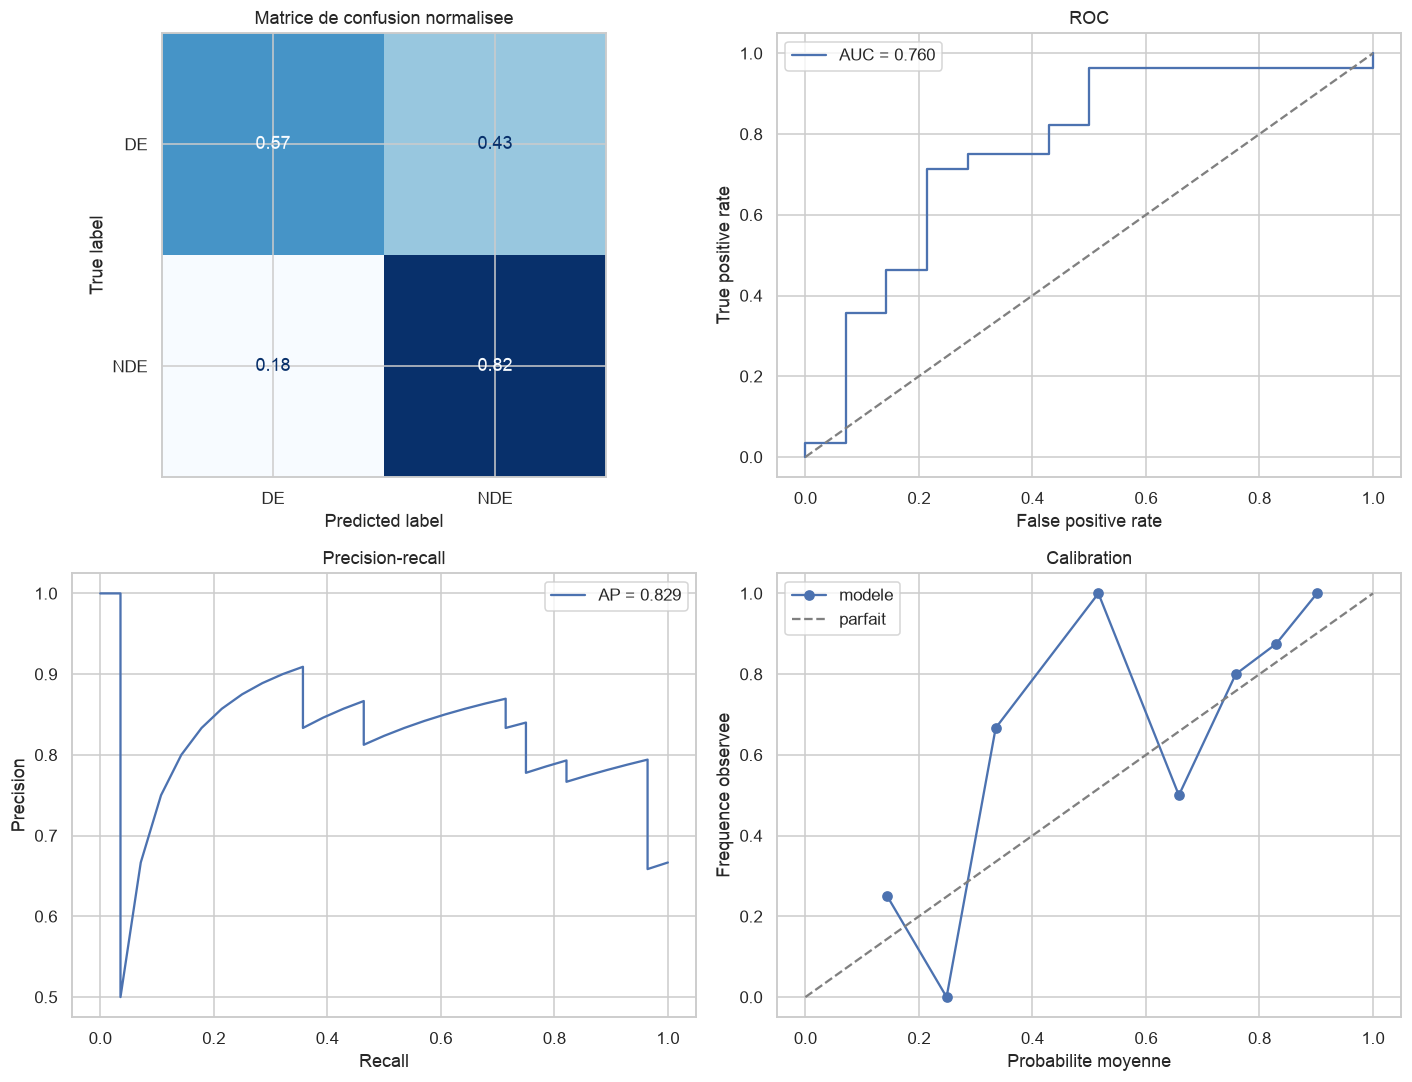

Seuil optimal selon F1 macro: {'threshold': 0.30499999999999994, 'accuracy': 0.8095238095238095, 'balanced_accuracy': 0.7321428571428572, 'macro_f1': 0.7536656891495601}
Sauvegarde: /Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b/analysis/threshold_sweep.png


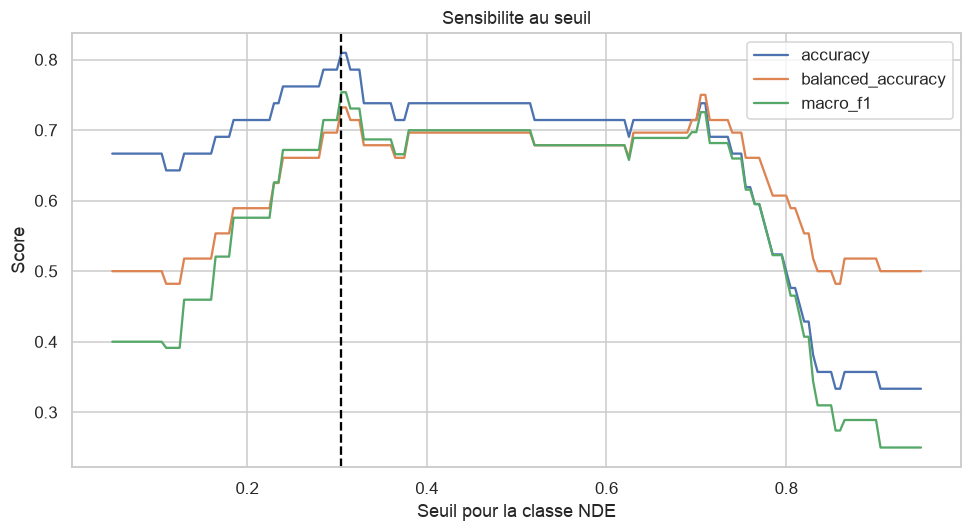

Erreurs les plus confiantes


,key,cluster_id,label,prediction,has_chandra,loss,probability_DE,probability_NDE,correct,confidence,margin,error_type
10,PSZ2G068.36+81.81.fits,PSZ2G068.36+81.81,1,0,False,2.223063,0.891723,0.108277,False,0.891723,0.783446,false_positive_for_DE
20,PSZ2G111.75+70.37.fits,PSZ2G111.75+70.37,0,1,True,1.983209,0.137627,0.862373,False,0.862373,0.724746,false_negative_for_DE
12,PSZ2G081.02+50.57.fits,PSZ2G081.02+50.57,0,1,False,1.590991,0.203724,0.796276,False,0.796276,0.592553,false_negative_for_DE
36,PSZ2G160.83+81.66.fits,PSZ2G160.83+81.66,0,1,True,1.436794,0.237689,0.762311,False,0.762311,0.524623,false_negative_for_DE
19,PSZ2G106.61+66.71.fits,PSZ2G106.61+66.71,0,1,True,1.207040,0.299081,0.700919,False,0.700919,0.401838,false_negative_for_DE
2,PSZ2G045.87+57.70.fits,PSZ2G045.87+57.70,0,1,False,1.173041,0.309425,0.690575,False,0.690575,0.381151,false_negative_for_DE
35,PSZ2G155.80+70.40.fits,PSZ2G155.80+70.40,1,0,False,1.163402,0.687579,0.312421,False,0.687579,0.375157,false_positive_for_DE
32,PSZ2G152.40+75.00.fits,PSZ2G152.40+75.00,1,0,False,1.120108,0.673755,0.326245,False,0.673755,0.347511,false_positive_for_DE
1,PSZ2G045.13+67.78.fits,PSZ2G045.13+67.78,1,0,False,1.119666,0.673611,0.326389,False,0.673611,0.347223,false_positive_for_DE
18,PSZ2G105.82-38.36.fits,PSZ2G105.82-38.36,1,0,False,1.008441,0.635213,0.364787,False,0.635213,0.270425,false_positive_for_DE


In [87]:
if test_eval is not None:
    y_true = test_eval['label'].astype(int).to_numpy()
    score = test_eval['probability_NDE'].astype(float).to_numpy()
    y_pred = test_eval['prediction'].astype(int).to_numpy()
    class_names = metrics.get('class_names', config_doc.get('class_names', ['DE', 'NDE']))

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[0, 0], values_format='.2f', cmap='Blues', colorbar=False
    )
    axes[0, 0].set_title('Matrice de confusion normalisee')

    fpr, tpr, _ = roc_curve(y_true, score)
    auc_value = roc_auc_score(y_true, score)
    axes[0, 1].plot(fpr, tpr, label=f'AUC = {auc_value:.3f}')
    axes[0, 1].plot([0, 1], [0, 1], '--', color='0.5')
    axes[0, 1].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC')
    axes[0, 1].legend()

    precision, recall, _ = precision_recall_curve(y_true, score)
    ap = average_precision_score(y_true, score)
    axes[1, 0].plot(recall, precision, label=f'AP = {ap:.3f}')
    axes[1, 0].set(xlabel='Recall', ylabel='Precision', title='Precision-recall')
    axes[1, 0].legend()

    prob_true, prob_pred = calibration_curve(y_true, score, n_bins=min(10, len(test_eval)))
    axes[1, 1].plot(prob_pred, prob_true, 'o-', label='modele')
    axes[1, 1].plot([0, 1], [0, 1], '--', color='0.5', label='parfait')
    axes[1, 1].set(xlabel='Probabilite moyenne', ylabel='Frequence observee', title='Calibration')
    axes[1, 1].legend()
    fig.tight_layout()
    _save(fig, 'test_diagnostics.png')
    plt.show()

    thresholds = np.linspace(0.05, 0.95, 181)
    threshold_rows = []
    for threshold in thresholds:
        pred = (score >= threshold).astype(int)
        threshold_rows.append({
            'threshold': threshold,
            'accuracy': (pred == y_true).mean(),
            'balanced_accuracy': balanced_accuracy_score(y_true, pred),
            'macro_f1': f1_score(y_true, pred, average='macro', zero_division=0),
        })
    threshold_table = pd.DataFrame(threshold_rows)
    best_threshold = threshold_table.loc[threshold_table['macro_f1'].idxmax()]
    print('Seuil optimal selon F1 macro:', best_threshold.to_dict())

    fig, ax = plt.subplots(figsize=(9, 5))
    for metric_name in ('accuracy', 'balanced_accuracy', 'macro_f1'):
        ax.plot(threshold_table['threshold'], threshold_table[metric_name], label=metric_name)
    ax.axvline(best_threshold['threshold'], color='black', linestyle='--')
    ax.set(xlabel='Seuil pour la classe NDE', ylabel='Score', title='Sensibilite au seuil')
    ax.legend()
    fig.tight_layout()
    _save(fig, 'threshold_sweep.png')
    plt.show()

    print('Erreurs les plus confiantes')
    display(test_eval.loc[~test_eval['correct']].sort_values('confidence', ascending=False).head(20))

## 4. Cohortes et biais de performance

Les sorties de `clusterprep` distinguent les exemples `paired` et `raw_only`. Le notebook recalcule aussi les scores selon `has_chandra` depuis le CSV, afin de detecter une degradation liee a la disponibilite des observations.

,n,accuracy,balanced_accuracy,macro_f1,roc_auc,average_precision,brier
cohort,,,,,,,
has_chandra=False,27,0.741,0.400,0.426,0.560,0.954,0.177
has_chandra=True,15,0.733,0.833,0.700,0.833,0.532,0.202


Sauvegarde: /Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b/analysis/cohort_comparison.png


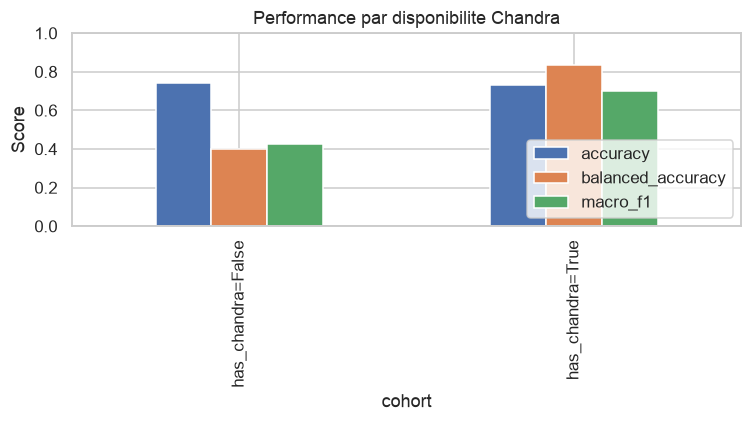

,n_samples,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_macro,average_precision_macro,loss
cohort,,,,,,,,
all,42,0.738,0.696,0.700,0.736,0.760,0.730,0.559
paired,15,0.733,0.833,0.700,0.760,0.833,0.746,0.597
raw_only,27,0.741,0.400,0.426,0.788,0.560,0.540,0.539


In [88]:
cohort_rows = []
if test_eval is not None and 'has_chandra' in test_eval:
    for cohort, frame in test_eval.groupby('has_chandra', dropna=False):
        row = _prediction_metrics(frame)
        row['cohort'] = f'has_chandra={cohort}'
        cohort_rows.append(row)

if cohort_rows:
    cohort_table = pd.DataFrame(cohort_rows).set_index('cohort')
    display(cohort_table.drop(columns=['confusion_matrix']).style.format(precision=3))

    fig, ax = plt.subplots(figsize=(7, 4))
    plot_data = cohort_table[['accuracy', 'balanced_accuracy', 'macro_f1']]
    plot_data.plot(kind='bar', ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title('Performance par disponibilite Chandra')
    ax.legend(loc='lower right')
    fig.tight_layout()
    _save(fig, 'cohort_comparison.png')
    plt.show()
else:
    print('La colonne has_chandra est absente des predictions.')

if metrics.get('test_cohorts'):
    cohort_metrics = []
    for name, data in metrics['test_cohorts'].items():
        if not data.get('metrics'):
            print(f'Attention: pas de metriques pour le cohort {name}.')
            continue
        row = {'cohort': name, **{k: v for k, v in data.get('metrics', {}).items() if np.isscalar(v)}}
        cohort_metrics.append(row)
    display(pd.DataFrame(cohort_metrics).set_index('cohort').style.format(precision=3))

## 5. Checkpoint, architecture et rapport

Cette section exploite les artefacts de modele sans relancer l'inference : taille du checkpoint, nombre de parametres, representation sauvegardee et contenu de `report.json` lorsqu'il existe.

In [89]:
checkpoint_path = run_dir / 'best.pt'
checkpoint_info = {
    'exists': checkpoint_path.exists(),
    'size_mb': round(checkpoint_path.stat().st_size / 1024**2, 2) if checkpoint_path.exists() else None,
}

if checkpoint_path.exists():
    try:
        import torch
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)

        def _find_state_dict(value):
            if isinstance(value, dict):
                tensor_values = [item for item in value.values() if hasattr(item, 'numel')]
                if tensor_values:
                    return value
                for item in value.values():
                    found = _find_state_dict(item)
                    if found is not None:
                        return found
            return None

        state_dict = _find_state_dict(checkpoint)
        tensors = list(state_dict.values()) if state_dict is not None else []
        checkpoint_info['tensor_count'] = len(tensors)
        checkpoint_info['parameter_count'] = int(sum(t.numel() for t in tensors if hasattr(t, 'numel')))
        checkpoint_info['state_keys'] = len(state_dict) if state_dict is not None else None
    except Exception as exc:
        checkpoint_info['load_error'] = repr(exc)

display(pd.Series(checkpoint_info, name='best.pt'))

if config_doc.get('model_repr'):
    print(config_doc['model_repr'])
if report:
    print('report.json')
    display(pd.Series(report))

exists              True
size_mb             0.84
tensor_count          65
parameter_count    69739
state_keys            65
Name: best.pt, dtype: object

ImageCNN(
  (encoder): ImageEncoder(
    (encoder): Sequential(
      (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
      (3): Dropout2d(p=0.3, inplace=False)
      (4): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (6): LeakyReLU(negative_slope=0.2)
      (7): Dropout2d(p=0.3, inplace=False)
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0.2)
      (12): Dropout2d(p=0.4, inplace=False)
    )
    (to_latent): Sequential(
      (0): Conv2d(32, 32, k

## 6. Export de la synthese

Un fichier JSON et un CSV des metriques recalculees sont ecrits dans le dossier `analysis` pour comparer plusieurs runs sans perdre la trace des parametres.

In [90]:
export_payload = {
    'run_dir': str(run_dir),
    'config': config,
    'summary': summary,
    'metrics_json': metrics,
    'prediction_metrics': prediction_metrics,
    'cohorts_recomputed': cohort_rows,
    'checkpoint': checkpoint_info,
    'artifacts': artifact_table.to_dict(orient='records'),
}
(output_dir / 'analysis_summary.json').write_text(json.dumps(export_payload, indent=2, default=str))

if prediction_metrics:
    pd.DataFrame(prediction_metrics).T.to_csv(output_dir / 'prediction_metrics.csv')

print(f'Synthese exportee dans {output_dir}')

Synthese exportee dans /Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c7a9b/analysis
